-*- encoding: utf-8 -*-
This file is part of GaPSE
Copyright (C) 2022 Matteo Foglieni
GaPSE is free software: you can redistribute it and/or modify
it under the terms of the GNU General Public License as published by
the Free Software Foundation, either version 3 of the License, or
(at your option) any later version.
GaPSE is distributed in the hope that it will be useful, but
WITHOUT ANY WARRANTY; without even the implied warranty of
MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. See the GNU
General Public License for more details.
You should have received a copy of the GNU General Public License
along with GaPSE. If not, see <http://www.gnu.org/licenses/>.

# spline_comparison

Since version 0.10.0 GaPSE interpolates with its own cubic spline, `MySpline`
(`src/Spline.jl`), at all the 61 construction sites in `src/`; before, it used
[Dierckx](https://github.com/kbarbary/Dierckx.jl), a wrapper of the FITPACK Fortran
routines. `Dierckx` is still a *test* dependency, where the suite uses it as an
independent cross-check.

This notebook measures the two sides of that replacement, **accuracy** and
**performance**, on three functions:

- $j_0(x) = \sin(x)/x$, a general smooth oscillating function. The exact values are
  known, so here we can speak of the *error* of each spline and not only of their
  difference;
- the input matter Power Spectrum $P(q)$, read from `data/WideA_ZA_pk.dat`: four
  decades of a positive function with one broad peak and a steep tail;
- $I_0^0(s)$, one of the $I_\ell^n$ integrals that build every TPCF, computed and
  sampled exactly as `IPSTools` does it.

Each one is plotted with the two splines on top of each other and their ratio
underneath, then the benchmarks close the notebook.

Two things are **not** interchangeable between the two, and are worth keeping in mind
while reading the plots:

- `MySpline` is built with `bc = "error"` at every site in `src/`, so it *throws*
  outside the range of its nodes, while `Spline1D` silently extrapolates. The
  comparisons below clamp the evaluation points into the node range for this reason -
  a logarithmic grid built from `xs[1]` and `xs[end]` can fall outside by one ULP;
- the two use different conditions at the two ends. `MySpline` offers three, selected
  by `ic`, and `src/` always takes the default `"Natural"`, i.e. $S'' = 0$ at the first
  and the last node. That is a second-order condition imposed on an interpolant that is
  fourth-order accurate in the interior, and it is where the two libraries differ most.


In [1]:
"""
    help(x)

Show the docstring of `x`. Useful in VSCode or Jupyter Lab, where prepending `?` doesn't work.
"""
macro help(x)
    quote
        display("text/markdown", @doc $x)
    end
end;
@help @help

```julia
help(x)
```

Show the docstring of `x`. Useful in VSCode or Jupyter Lab, where prepending `?` doesn't work.


## GaPSE setup

In [2]:
using GaPSE
using Plots, LaTeXStrings, DelimitedFiles, Printf
using SpecialFunctions: sphericalbesselj
import Dierckx, BenchmarkTools
using BenchmarkTools: @belapsed, @ballocated

# GR, the default Plots backend: it needs no Python at all, and it is the one that
# works under Julia 1.12 - see the "Which backend" section of ../ipynbs/README.md
gr()

# one second per measurement is plenty for what is timed here, and it keeps the
# benchmark cells in the tens of seconds instead of minutes
BenchmarkTools.DEFAULT_PARAMETERS.seconds = 1.0;

In [3]:
const PATH_TO_GAPSE = normpath(joinpath(@__DIR__, ".."));
# Input matter Power Spectrum P(q) at z=0
const FILE_PS = joinpath(PATH_TO_GAPSE, "data", "WideA_ZA_pk.dat");

In [4]:
const DIR = joinpath(@__DIR__, "spline_comparison");
@assert isdir(DIR) "ERROR: DIR=$DIR DOESN'T EXIST!!!"

## The three functions

In [5]:
"""
    j0(x) :: Float64

The spherical Bessel function ``j_0(x) = \\sin(x)/x``, with the removable singularity
in ``x = 0`` already removed by `SpecialFunctions`.
"""
j0(x) = sphericalbesselj(0, x);
@help j0

```julia
j0(x) :: Float64
```

The spherical Bessel function $j_0(x) = \sin(x)/x$, with the removable singularity in $x = 0$ already removed by `SpecialFunctions`.


In [6]:
# the input P(q), both as the `InputPS` GaPSE builds out of it and as the raw table,
# because the nodes of the comparison must be the tabulated points themselves
const IPS = GaPSE.InputPS(FILE_PS);
const TAB = readdlm(FILE_PS, comments=true);
const KS, PKS = collect(TAB[:, 1]), collect(TAB[:, 2]);
@printf("the input file tabulates %d points, from q = %.3e to q = %.3e h/Mpc\n",
    length(KS), KS[1], KS[end])

the input file tabulates 421 points, from q = 2.056e-07 to q = 2.023e+01 h/Mpc


In [7]:
# I_0^0(s), with the arguments `IPSTools` hard-codes for its `xicalc` calls
const RS, XIS = GaPSE.TwoFAST.xicalc(IPS, 0, 0; N=1024, kmin=1e-5, kmax=1e3, r0=1e-3);

# `IntegralIPS` splines only the nodes between `fit_min` and the second-to-last one,
# replacing the two tails with power-law fits; these are exactly those nodes.
const FIT_MIN = 0.05;
const I_LEFT = findfirst(x -> x > FIT_MIN, RS) - 1;
const I_RIGHT = length(RS) - 1;
const SS, I00S = collect(RS[I_LEFT:I_RIGHT]), collect(XIS[I_LEFT:I_RIGHT]);
@printf("I_0^0 is splined over %d nodes, from s = %.3e to s = %.3e Mpc/h\n",
    length(SS), SS[1], SS[end])

I_0^0 is splined over 806 nodes, from s = 4.958e-02 to s = 9.647e+04 Mpc/h


## Plot and table functions

In [8]:
function plot_kwargs(kwargs...)
    defaults = Dict(
        :size => (1000, 560), :dpi => 200, :legendposition => :outerright,
        :legendfontsize => 10, :guidefontsize => 13, :tickfontsize => 10,
        :titlefontsize => 15, :left_margin => 12Plots.mm,
        :bottom_margin => 6Plots.mm, :yguidefontrotation => -90,
    )
    merge(defaults, Dict(kwargs))
end

# the ylabel is rotated horizontal, so it needs some room on its right
hlabel(s; pad=4) = s * " "^pad

logticks(lo, hi; step=1) = 10.0 .^ (floor(Int, log10(lo)):step:ceil(Int, log10(hi)))

logticks (generic function with 1 method)

In [9]:
"""
    compare(xs, ys, zs; title, xlabel, ylabel, exact=nothing,
        xscale=:identity, yscale=:identity, ic="Natural", toppad=10,
        ratio_ylims=(0.95, 1.05), zero_tol=1e-3) :: Plots.Plot

Spline the nodes `(xs, ys)` with both libraries and evaluate them in `zs`.

The upper panel shows the two interpolants, `Dierckx` dashed blue and `MySpline` solid
red, plus the `exact` values when they are known; the lower one, vertically smaller,
shows their ratio in green.

`toppad` pads the labels of the upper legend with trailing spaces: an `:outerright`
legend is as wide as its longest entry and that width is taken out of the plot area,
so the two panels share the same x axis only if their legends are equally wide.

`MySpline` is built with `bc = "error"` and refuses anything outside the node range,
which a logarithmic grid can hit by one ULP, hence the `clamp`; `Dierckx` would
extrapolate instead.

The ratio is masked wherever `|Dierckx| < zero_tol * maximum(|Dierckx|)`: where the
function itself crosses zero, `a/b` with both vanishing says nothing about either
spline. Pass `zero_tol = 0.0` for a function of constant sign.
"""
function compare(xs, ys, zs; title="", xlabel="x", ylabel="f(x)",
                 exact=nothing, xscale=:identity, yscale=:identity,
                 ic="Natural", toppad=10, ratio_ylims=(0.95, 1.05), zero_tol=1e-3)
    zs = clamp.(zs, xs[1], xs[end])

    ms = GaPSE.MySpline(xs, ys; ic=ic)
    ds = Dierckx.Spline1D(xs, ys)
    vm = [ms(z) for z in zs]
    vd = [ds(z) for z in zs]

    top = plot(; xscale=xscale, yscale=yscale, xlabel="", ylabel=hlabel(ylabel),
        title=title, plot_kwargs(:bottom_margin => 0Plots.mm,
                                 :left_margin => 16Plots.mm)...)
    isnothing(exact) || plot!(top, zs, exact; label="exact" * " "^toppad,
        c=:black, ls=:dot, lw=4)
    plot!(top, zs, vd; label="Dierckx" * " "^toppad, c=:blue, ls=:dash, lw=3)
    plot!(top, zs, vm; label="MySpline" * " "^toppad, c=:red, ls=:solid, lw=2)
    xscale == :log10 && plot!(top, xticks=logticks(zs[1], zs[end]))
    yscale == :log10 && plot!(top, yticks=logticks(minimum(abs, vd), maximum(abs, vd)))

    r = vm ./ vd
    r[abs.(vd).<zero_tol*maximum(abs, vd)] .= NaN

    bot = plot(; xscale=xscale, xlabel=xlabel, ylabel=hlabel("ratio"),
        ylims=ratio_ylims, yticks=range(ratio_ylims...; length=5),
        plot_kwargs(:left_margin => 16Plots.mm)...)
    xscale == :log10 && plot!(bot, xticks=logticks(zs[1], zs[end]))
    hline!(bot, [1.0]; c=:black, ls=:dash, lw=2, alpha=0.55, label="")
    plot!(bot, zs, r; label="MySpline / Dierckx", c=:green, lw=3)

    plot(top, bot; layout=grid(2, 1, heights=[0.70, 0.30]), size=(1000, 620), link=:x)
end;
@help compare

```julia
compare(xs, ys, zs; title, xlabel, ylabel, exact=nothing,
    xscale=:identity, yscale=:identity, ic="Natural", toppad=10,
    ratio_ylims=(0.95, 1.05), zero_tol=1e-3) :: Plots.Plot
```

Spline the nodes `(xs, ys)` with both libraries and evaluate them in `zs`.

The upper panel shows the two interpolants, `Dierckx` dashed blue and `MySpline` solid red, plus the `exact` values when they are known; the lower one, vertically smaller, shows their ratio in green.

`toppad` pads the labels of the upper legend with trailing spaces: an `:outerright` legend is as wide as its longest entry and that width is taken out of the plot area, so the two panels share the same x axis only if their legends are equally wide.

`MySpline` is built with `bc = "error"` and refuses anything outside the node range, which a logarithmic grid can hit by one ULP, hence the `clamp`; `Dierckx` would extrapolate instead.

The ratio is masked wherever `|Dierckx| < zero_tol * maximum(|Dierckx|)`: where the function itself crosses zero, `a/b` with both vanishing says nothing about either spline. Pass `zero_tol = 0.0` for a function of constant sign.


In [10]:
"""
    errplot(xs, ys, zs, truth; title, xlabel, xscale=:identity,
        ylims=(1e-11, 2e-2), ics=("Natural", "Parabolic", "ThirdDerivative")
    ) :: Plots.Plot

`|spline - exact|` on a logarithmic vertical axis, for `Dierckx` and for `MySpline`
with each one of the three `ics`. Only usable where the exact `truth` is known.
"""
function errplot(xs, ys, zs, truth; title="", xlabel="x", xscale=:identity,
                 ylims=(1e-11, 2e-2), ics=("Natural", "Parabolic", "ThirdDerivative"))
    zs = clamp.(zs, xs[1], xs[end])
    p = plot(; xscale=xscale, yscale=:log10, xlabel=xlabel, ylims=ylims,
        ylabel=hlabel(L"|\mathrm{spline} - \mathrm{exact}|"; pad=2), title=title,
        yticks=logticks(ylims...), plot_kwargs(:left_margin => 18Plots.mm)...)
    ds = Dierckx.Spline1D(xs, ys)
    # the +1e-20 only keeps the exact zeros off a logarithmic axis
    plot!(p, zs, abs.([ds(z) for z in zs] .- truth) .+ 1e-20;
        label="Dierckx", c=:blue, ls=:dash, lw=3)
    for (ic, col) in zip(ics, (:red, :orange, :purple))
        ms = GaPSE.MySpline(xs, ys; ic=ic)
        plot!(p, zs, abs.([ms(z) for z in zs] .- truth) .+ 1e-20;
            label="MySpline, ic=\"$ic\"", c=col, lw=2)
    end
    p
end;
@help errplot

```julia
errplot(xs, ys, zs, truth; title, xlabel, xscale=:identity,
    ylims=(1e-11, 2e-2), ics=("Natural", "Parabolic", "ThirdDerivative")
) :: Plots.Plot
```

`|spline - exact|` on a logarithmic vertical axis, for `Dierckx` and for `MySpline` with each one of the three `ics`. Only usable where the exact `truth` is known.


In [11]:
"""
    convergence_table(Ns; f=j0, a=0.0, b=20.0, nz=8000, interior=false, io=stdout,
        ics=("Natural", "Parabolic", "ThirdDerivative"))

For every `N` in `Ns`, print `max |spline - f|` over `nz` points of `[a, b]`, for
`Dierckx` and for `MySpline` with each one of the `ics`.

With `interior = true` the maximum is taken over the central 80% of the range only,
which cuts out the two end intervals where the `ic` acts.
"""
function convergence_table(Ns; f=j0, a=0.0, b=20.0, nz=8000, interior=false,
                           io=stdout, ics=("Natural", "Parabolic", "ThirdDerivative"))
    zs = collect(range(a, b, length=nz))
    truth = f.(zs)
    rng = interior ? (round(Int, 0.1nz):round(Int, 0.9nz)) : (1:nz)
    @printf(io, "%6s | %11s", "N", "Dierckx")
    for ic in ics
        @printf(io, " %16s", ic)
    end
    @printf(io, "\n%s\n", "-"^(6 + 3 + 11 + 17 * length(ics)))
    for N in Ns
        xs = collect(range(a, b, length=N))
        ys = f.(xs)
        ds = Dierckx.Spline1D(xs, ys)
        @printf(io, "%6d | %11.3e", N,
            maximum(abs, [ds(z) for z in zs[rng]] .- truth[rng]))
        for ic in ics
            ms = GaPSE.MySpline(xs, ys; ic=ic)
            @printf(io, " %16.3e",
                maximum(abs, [ms(z) for z in zs[rng]] .- truth[rng]))
        end
        println(io)
    end
end;
@help convergence_table

```julia
convergence_table(Ns; f=j0, a=0.0, b=20.0, nz=8000, interior=false, io=stdout,
    ics=("Natural", "Parabolic", "ThirdDerivative"))
```

For every `N` in `Ns`, print `max |spline - f|` over `nz` points of `[a, b]`, for `Dierckx` and for `MySpline` with each one of the `ics`.

With `interior = true` the maximum is taken over the central 80% of the range only, which cuts out the two end intervals where the `ic` acts.


In [12]:
"""
    max_reldiff(xs, ys; nz=4000, logscale=true) :: Float64

`max |MySpline(z) / Dierckx(z) - 1|` over `nz` points spanning the nodes `(xs, ys)`.
This is the number that matters for GaPSE: not the error of either spline, but how
much the results can move by having changed library.
"""
function max_reldiff(xs, ys; nz=4000, logscale=true)
    zs = logscale ? 10 .^ range(log10(xs[1]), log10(xs[end]), length=nz) :
         collect(range(xs[1], xs[end], length=nz))
    zs = clamp.(zs, xs[1], xs[end])
    ms = GaPSE.MySpline(xs, ys)
    ds = Dierckx.Spline1D(xs, ys)
    maximum(abs(ms(z) / ds(z) - 1) for z in zs)
end;
@help max_reldiff

```julia
max_reldiff(xs, ys; nz=4000, logscale=true) :: Float64
```

`max |MySpline(z) / Dierckx(z) - 1|` over `nz` points spanning the nodes `(xs, ys)`. This is the number that matters for GaPSE: not the error of either spline, but how much the results can move by having changed library.


In [13]:
"""
    bench_table(Ns; f=j0, a=0.0, b=20.0, z=13.7, io=stdout)

For every `N` in `Ns`, time the *construction* of the two splines over `N` nodes of
`f` in `[a, b]`, and one *evaluation* of each in `z`, and print the two ratios.
"""
function bench_table(Ns; f=j0, a=0.0, b=20.0, z=13.7, io=stdout)
    @printf(io, "%7s | %11s %11s %6s | %11s %11s %6s\n", "N",
        "build My", "build Dx", "ratio", "call My", "call Dx", "ratio")
    @printf(io, "%s\n", "-"^(7 + 3 + 11 + 12 + 7 + 3 + 11 + 12 + 7))
    for N in Ns
        xs = collect(range(a, b, length=N))
        ys = f.(xs)
        ms = GaPSE.MySpline(xs, ys)
        ds = Dierckx.Spline1D(xs, ys)
        bm = @belapsed GaPSE.MySpline($xs, $ys)
        bd = @belapsed Dierckx.Spline1D($xs, $ys)
        cm = @belapsed $ms($z)
        cd = @belapsed $ds($z)
        @printf(io, "%7d | %11.3e %11.3e %6.1f | %11.3e %11.3e %6.1f\n",
            N, bm, bd, bd / bm, cm, cd, cd / cm)
    end
end;
@help bench_table

```julia
bench_table(Ns; f=j0, a=0.0, b=20.0, z=13.7, io=stdout)
```

For every `N` in `Ns`, time the *construction* of the two splines over `N` nodes of `f` in `[a, b]`, and one *evaluation* of each in `z`, and print the two ratios.


In [14]:
function save_plot(p, name)
    savefig(p, joinpath(DIR, name))
    nothing
end;

## A general function: $j_0(x)$

60 nodes over $[0, 20]$, i.e. about 9 nodes per oscillation: few enough that the
interpolation error is visible, many enough that both splines are in their asymptotic
regime. Since $j_0$ crosses zero six times in this range, the ratio is masked around
each crossing, where it only measures the distance between two zeros.

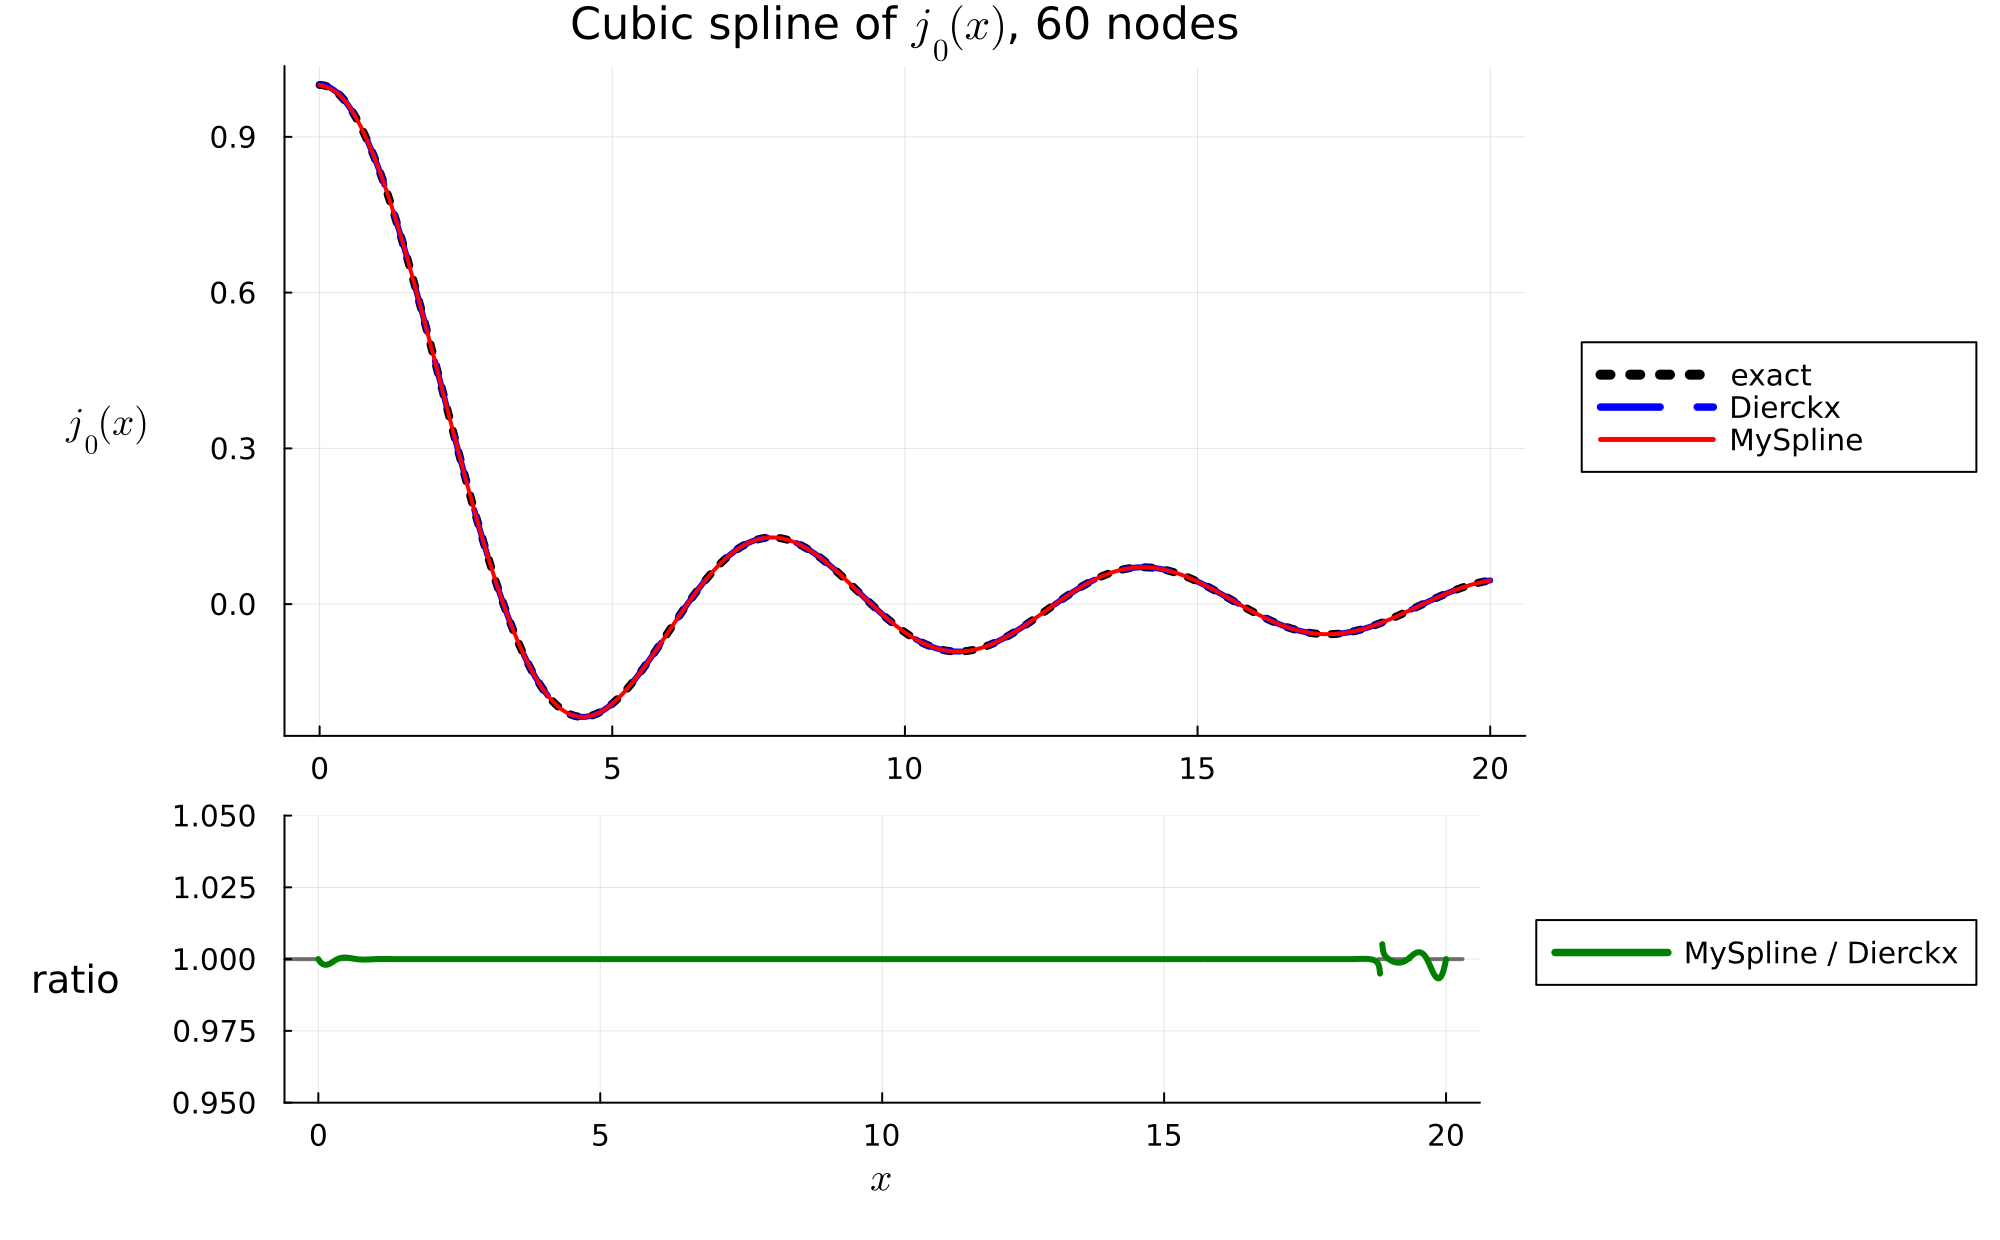

In [15]:
const XS1 = collect(range(0.0, 20.0, length=60));
const YS1 = j0.(XS1);
const ZS1 = collect(range(0.0, 20.0, length=2000));

p_j0 = compare(XS1, YS1, ZS1; exact=j0.(ZS1), xlabel=L"x", ylabel=L"j_0(x)",
    title="Cubic spline of " * L"j_0(x)" * ", 60 nodes")
save_plot(p_j0, "spline_j0.png")
p_j0

In [16]:
let zs = clamp.(ZS1, XS1[1], XS1[end])
    ms = GaPSE.MySpline(XS1, YS1)
    ds = Dierckx.Spline1D(XS1, YS1)
    d = [abs(ms(z) - ds(z)) for z in zs] ./ maximum(abs, YS1)
    i1, i2 = round(Int, 0.1length(zs)), round(Int, 0.9length(zs))
    @printf("max |MySpline - Dierckx| / max|j_0|, 60 nodes:\n")
    @printf("  over the whole [0, 20]      : %.3e\n", maximum(d))
    @printf("  over the central 80%% of it  : %.3e\n", maximum(d[i1:i2]))
end

max |MySpline - Dierckx| / max|j_0|, 60 nodes:
  over the whole [0, 20]      : 1.968e-03
  over the central 80% of it  : 7.285e-07


The two splines and the exact function are indistinguishable at this scale. The
ratio is flat at 1 over most of the range and leaves the panel only in the first and in
the last interval; the gaps are the six zeros of $j_0$, masked because the ratio of two
vanishing numbers says nothing. The cell above puts a number on both regions, and the
next plot explains the difference between them.

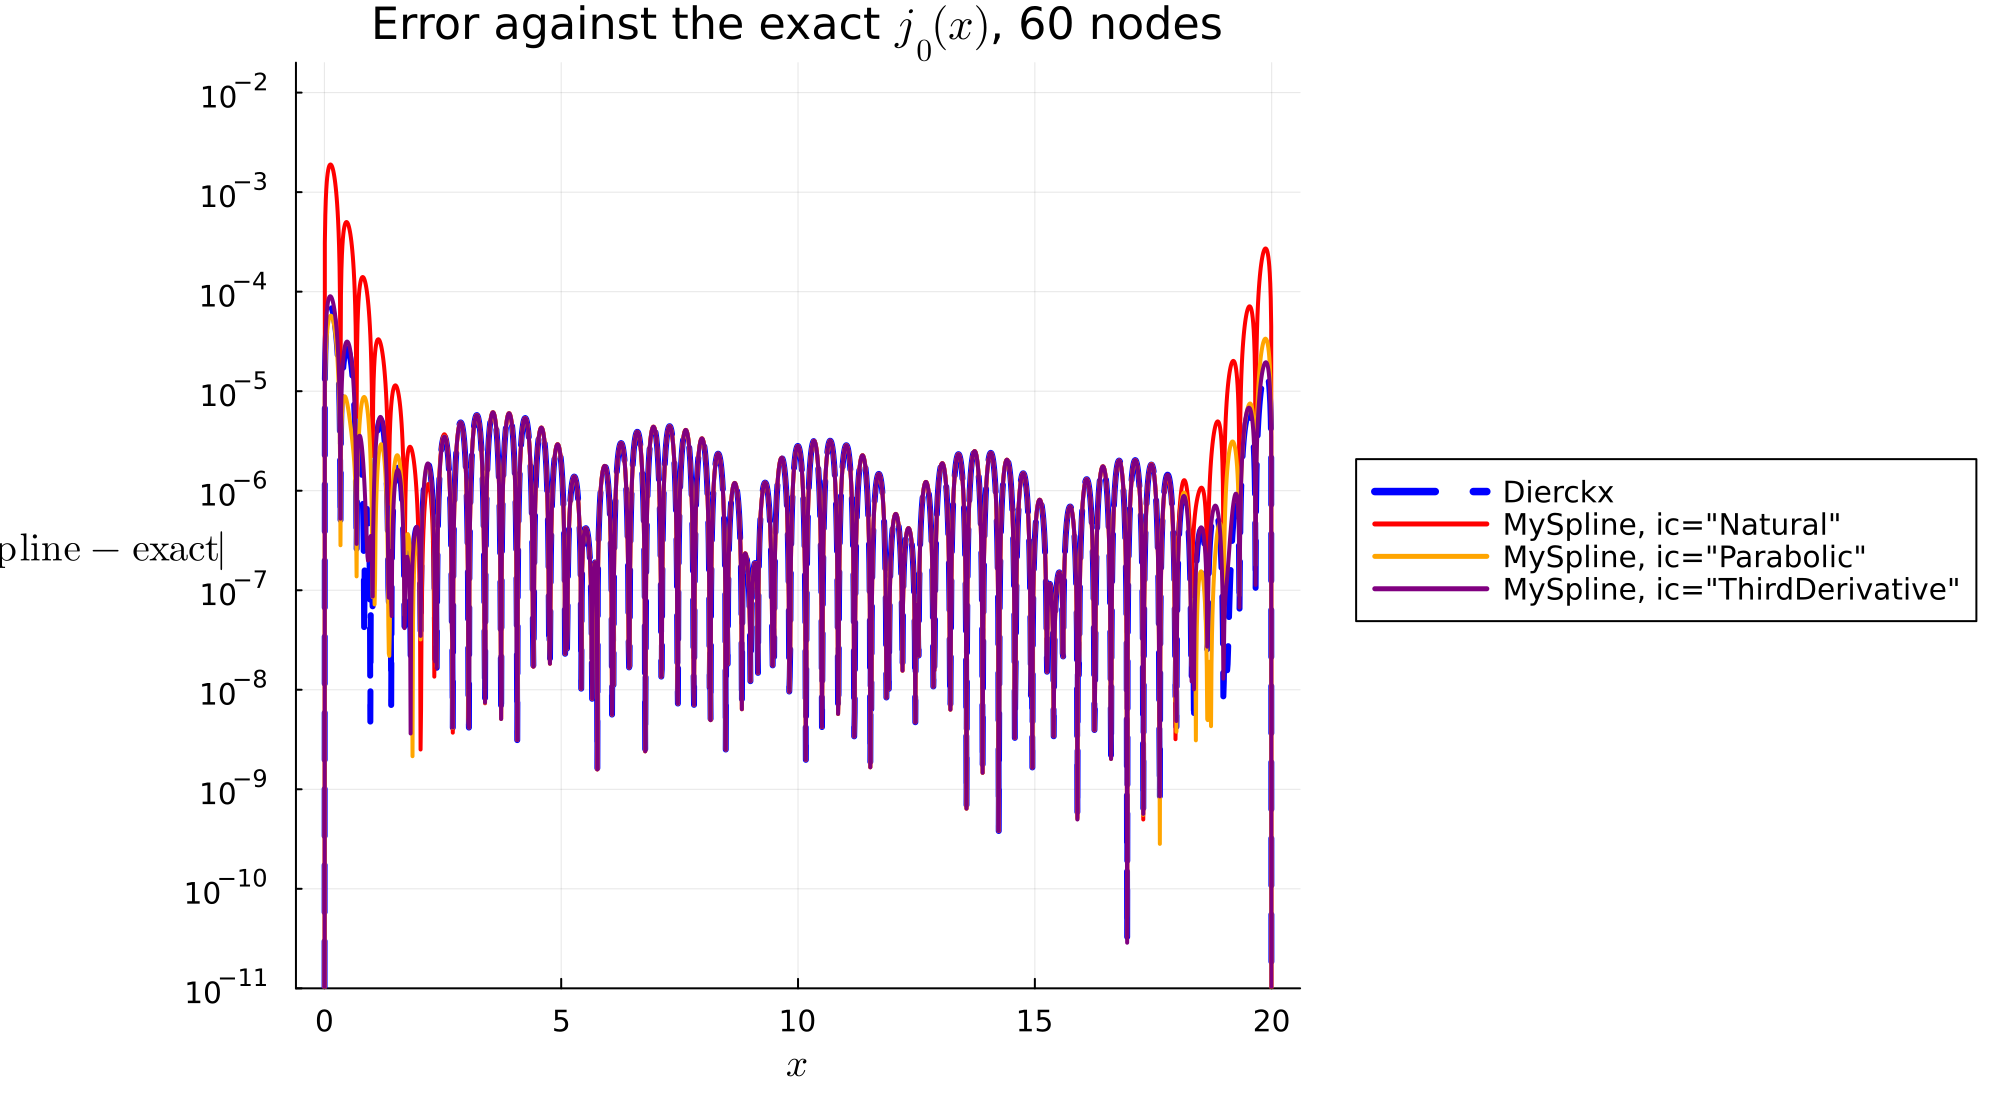

In [17]:
p_j0_err = errplot(XS1, YS1, ZS1, j0.(ZS1); xlabel=L"x",
    title="Error against the exact " * L"j_0(x)" * ", 60 nodes")
save_plot(p_j0_err, "spline_j0_error.png")
p_j0_err

Three things to read off this figure.

- In the **interior** the two libraries are the same method - the same tridiagonal
  system for the second derivatives of an interpolating cubic spline - and their error
  curves lie on top of each other, with the familiar $\mathcal{O}(h^4)$ bumps peaking
  in the middle of each interval.
- At the **two ends** the `"Natural"` condition $S'' = 0$ costs two to three orders of
  magnitude, because $j_0''(0) \neq 0$: there the error is $\mathcal{O}(h^2)$ and not
  $\mathcal{O}(h^4)$. This is the single source of every disagreement seen in the
  panels above.
- `"Parabolic"` and `"ThirdDerivative"` do not pay that price, and stay with `Dierckx`
  up to the boundary. `src/` uses `"Natural"` everywhere, since it is the default of
  the constructor.

## Convergence with the number of nodes

The same measurement over the whole range and over the central 80%, as the nodes are
doubled. A fourth-order method divides its error by 16 at every doubling, a
second-order one by 4.

In [18]:
const NS = [30, 60, 120, 240, 480];
println("max |spline - j_0| over the WHOLE range [0, 20]:")
convergence_table(NS)
println("\nmax |spline - j_0| over the central 80% of [0, 20]:")
convergence_table(NS; interior=true)

max |spline - j_0| over the WHOLE range [0, 20]:
     N |     Dierckx          Natural        Parabolic  ThirdDerivative
-----------------------------------------------------------------------
    30 |   1.049e-03        8.078e-03        9.858e-04        1.230e-03
    60 |   7.131e-05        1.897e-03        5.740e-05        8.999e-05
   120 |   4.459e-06        4.632e-04        3.467e-06        5.720e-06
   240 |   2.763e-07        1.146e-04        3.526e-07        3.557e-07
   480 |   1.716e-08        2.846e-05        4.051e-08        2.211e-08

max |spline - j_0| over the central 80% of [0, 20]:
     N |     Dierckx          Natural        Parabolic  ThirdDerivative
-----------------------------------------------------------------------
    30 |   1.103e-04        2.072e-04        1.129e-04        1.101e-04
    60 |   6.148e-06        6.145e-06        6.148e-06        6.148e-06
   120 |   3.663e-07        3.663e-07        3.663e-07        3.663e-07
   240 |   2.243e-08        2.243e

In the interior the four columns are the *same number* to three digits and fall
by a factor $\simeq 16$ per doubling: one fourth-order method, four end conditions.
Over the whole range the `"Natural"` column falls by $\simeq 4$ instead, so it is
asymptotically the worst of the four, while `Dierckx`, `"Parabolic"` and
`"ThirdDerivative"` keep their fourth order up to the boundary - `Dierckx` with a
prefactor about ten times larger than in the interior, the other two with none.

## The input Power Spectrum $P(q)$

Here there is no exact answer to compare against: the tabulated $P(q)$ *is* the data.
To see anything at all, the splines are built on **one node out of 8** of the input
file, so that the remaining points act as a reference; the number at the real node
density is measured further down. Note that both axes are logarithmic while the two
splines are cubic in the *linear* variables, as GaPSE uses them.

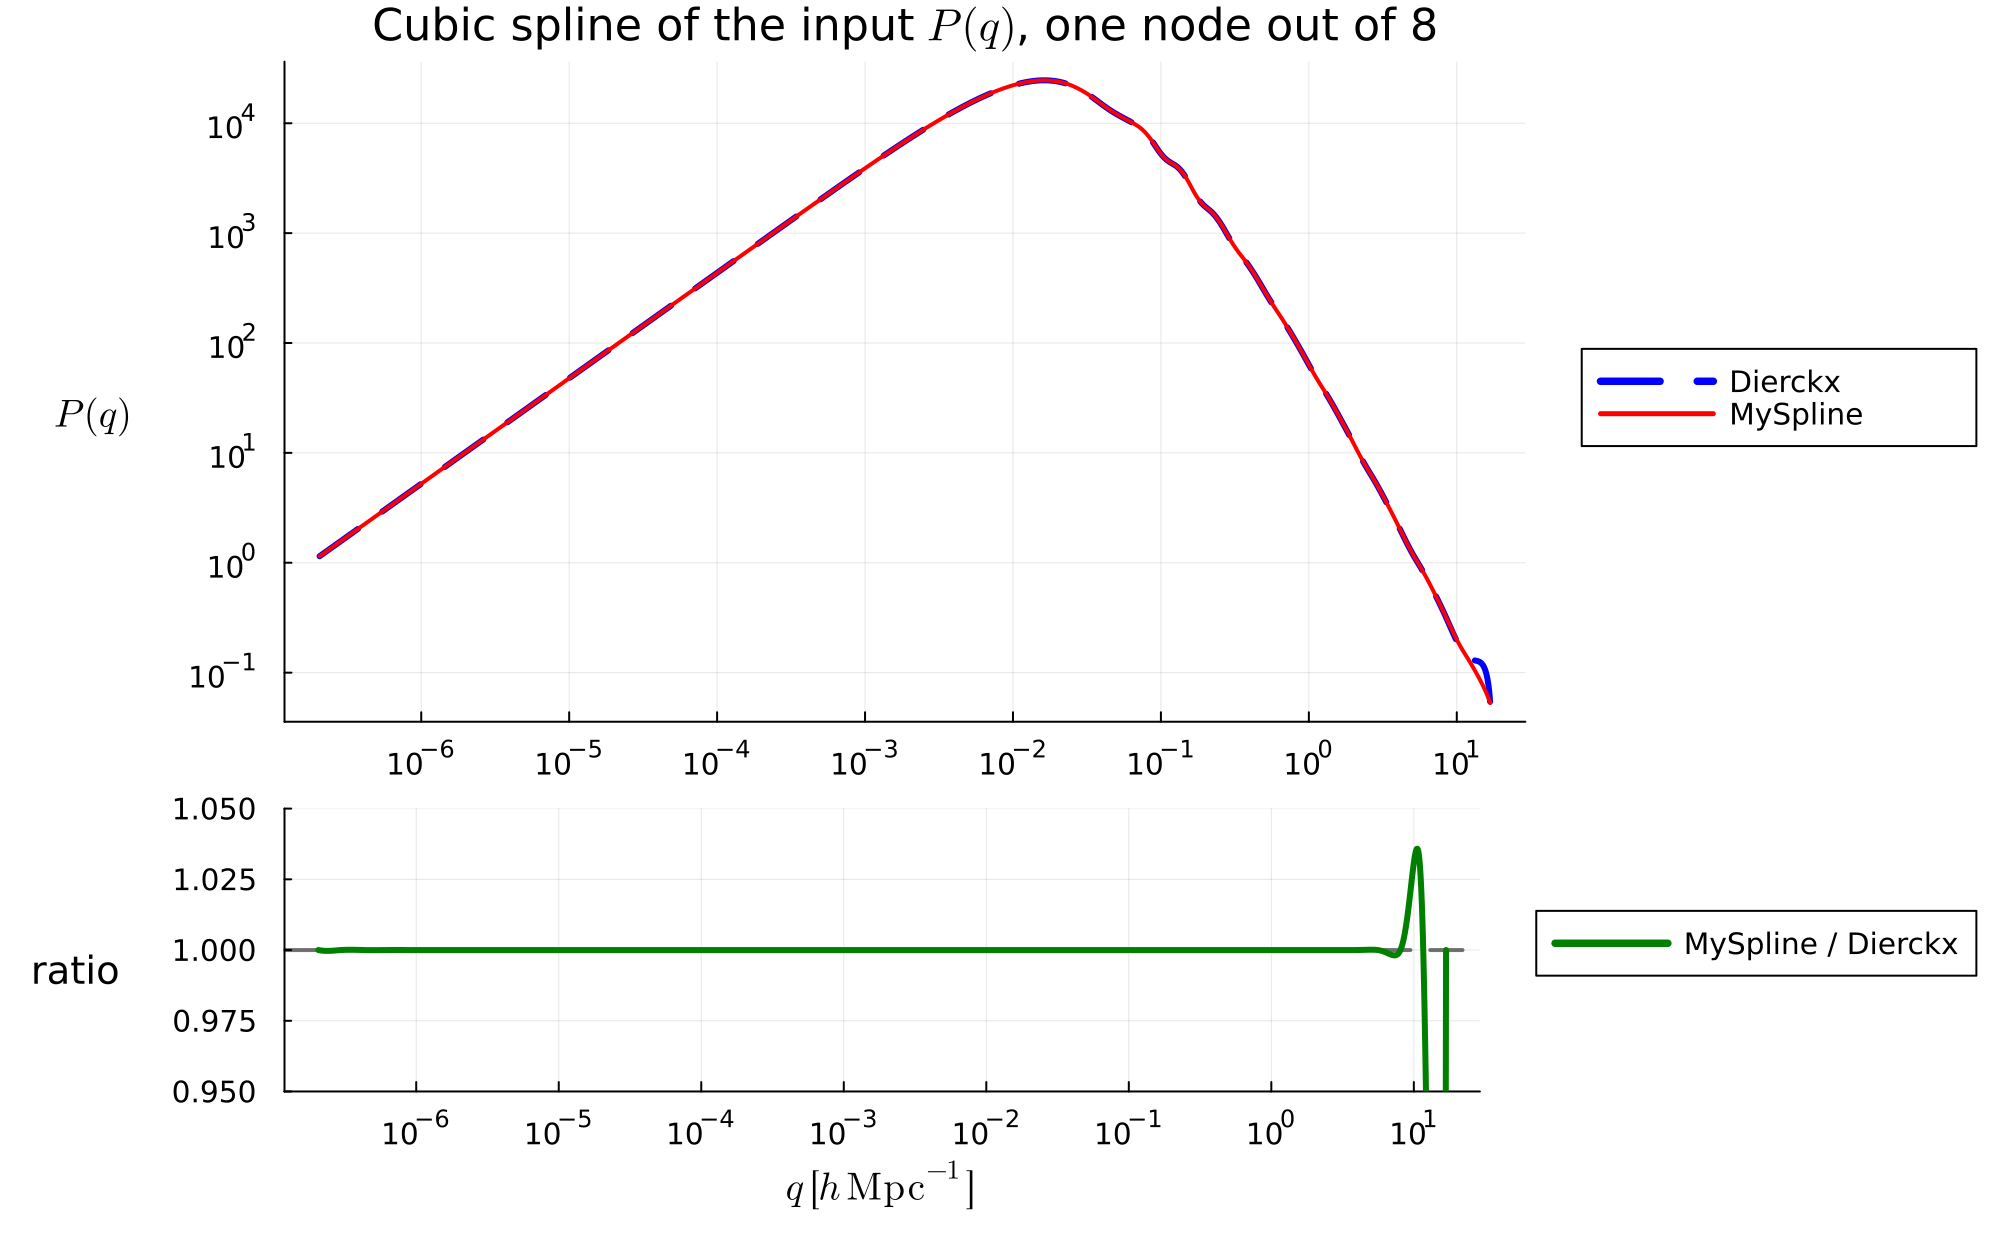

In [19]:
const SEL2 = 1:8:length(KS);
const XS2, YS2 = KS[SEL2], PKS[SEL2];
const ZS2 = collect(10 .^ range(log10(XS2[1]), log10(XS2[end]), length=2000));

p_Pq = compare(XS2, YS2, ZS2; xscale=:log10, yscale=:log10, zero_tol=0.0,
    xlabel=L"q \; [h \, \mathrm{Mpc}^{-1}]", ylabel=L"P(q)",
    title="Cubic spline of the input " * L"P(q)" * ", one node out of 8")
save_plot(p_Pq, "spline_Pq.png")
p_Pq

$P(q)$ has a definite sign, so the ratio needs no mask. Again the disagreement
lives at the two ends of the range - on the left, where $P \propto q$, the second
derivative that `"Natural"` sets to zero is the largest of the whole curve.

## One of the $I_\ell^n$: $I_0^0(s)$

$I_0^0$ is the $\ell = 0$, $n = 0$ member of

$$ I_\ell^n(s) = \frac{1}{2\pi^2} \int_0^\infty \mathrm{d}q \; q^2 \, P(q) \,
   \frac{j_\ell(qs)}{(qs)^n} \; , $$

and the spline over it is built, inside `IntegralIPS`, on the `xicalc` output itself.
As above, one node out of 4 is kept so that the two splines can be told apart.

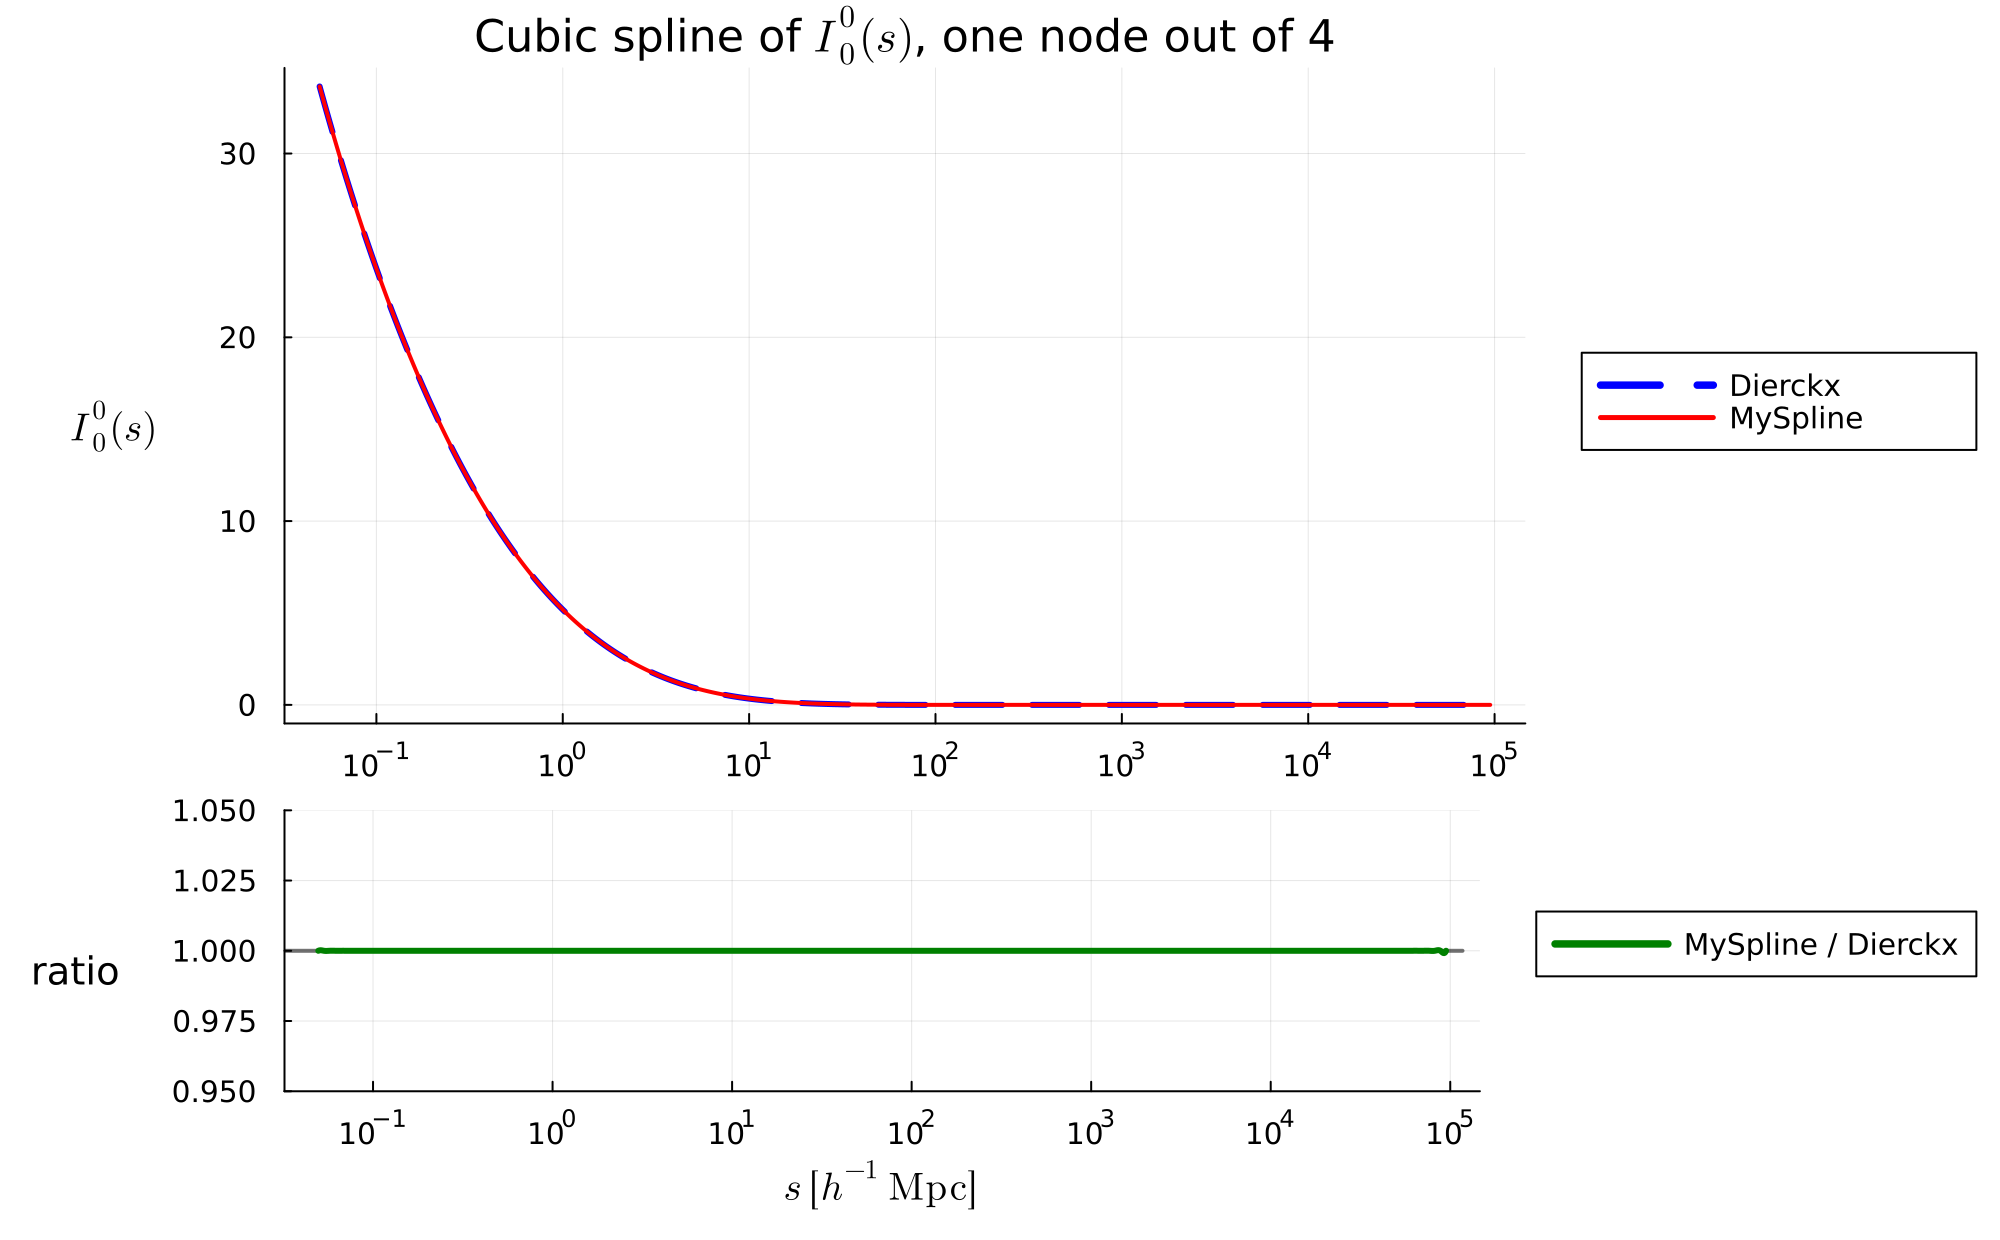

In [28]:
const SEL3 = 1:4:length(SS);
const XS3, YS3 = SS[SEL3], I00S[SEL3];
const ZS3 = collect(10 .^ range(log10(XS3[1]), log10(XS3[end]), length=2000));

p_I00 = compare(XS3, YS3, ZS3; xscale=:log10, yscale=:scalar, zero_tol=0.0,
    xlabel=L"s \; [h^{-1} \, \mathrm{Mpc}]", ylabel=L"I_0^0(s)",
    title="Cubic spline of " * L"I_0^0(s)" * ", one node out of 4")
save_plot(p_I00, "spline_I00.png")
p_I00

## At the node density GaPSE actually uses

Everything above was measured on deliberately coarsened node sets. The relevant
question is a different one: evaluated on **all** the nodes GaPSE really builds its
splines on, how far apart are the two libraries?

In [21]:
@printf("max |MySpline / Dierckx - 1| at the node density of GaPSE:\n\n")
@printf("  %-12s %5d nodes   %.3e\n", "P(q)", length(KS), max_reldiff(KS, PKS))
@printf("  %-12s %5d nodes   %.3e\n", "I_0^0(s)", length(SS), max_reldiff(SS, I00S))
@printf("\nand on the coarsened sets of the plots above:\n\n")
@printf("  %-12s %5d nodes   %.3e\n", "P(q)/8", length(XS2), max_reldiff(XS2, YS2))
@printf("  %-12s %5d nodes   %.3e\n", "I_0^0(s)/4", length(XS3), max_reldiff(XS3, YS3))

max |MySpline / Dierckx - 1| at the node density of GaPSE:

  P(q)           421 nodes   8.713e-04
  I_0^0(s)       806 nodes   2.510e-04

and on the coarsened sets of the plots above:

  P(q)/8          53 nodes   3.538e-01
  I_0^0(s)/4     202 nodes   8.381e-04


So the end conditions are worth knowing about, but they are not a problem at the
settings GaPSE runs with: the two libraries agree to better than 0.1% everywhere, and
the peak of the disagreement sits in the first and last interval of the node range -
which, for the $I_\ell^n$, is precisely where `IntegralIPS` stops using the spline and
switches to its power-law fits.

## Performance

Two things are worth timing separately.

- **Construction.** It happens once per spline, but a `Cosmology` builds a few tens of
  them (61 construction sites in `src/`), some over a thousand nodes, so it is part of
  the start-up cost of every run.
- **Evaluation.** This is the one that matters: every TPCF integrand calls several
  splines, and the quadratures call the integrands millions of times.

In [22]:
bench_table([100, 1_000, 10_000, 100_000])

      N |    build My    build Dx  ratio |     call My     call Dx  ratio
-------------------------------------------------------------------------
    100 |   2.060e-06   6.275e-06    3.0 |   1.557e-08   5.335e-08    3.4
   1000 |   1.508e-05   6.217e-05    4.1 |   2.927e-08   2.851e-07    9.7
  10000 |   1.447e-04   6.404e-04    4.4 |   4.045e-08   2.426e-06   60.0
 100000 |   1.442e-03   6.509e-03    4.5 |   6.004e-08   2.388e-05  397.7


`MySpline` builds in a fraction of the time, and the gap on the *calls* grows
with `N`. That is not a constant factor to be explained away by the Fortran wrapper: it
is a different complexity. `MySpline` locates the interval with
`searchsortedlast`, a binary search, so a call is $\mathcal{O}(\log N)$; FITPACK's
`splev` scans the knots linearly from the start, so it is $\mathcal{O}(N)$. At the
sizes GaPSE uses - $10^3$ nodes - this is already a factor of several tens.

In [23]:
# and it is not an allocation artefact either: neither call allocates
let xs = collect(range(0.0, 20.0, length=10_000)), ys = j0.(xs), z = 13.7
    ms = GaPSE.MySpline(xs, ys)
    ds = Dierckx.Spline1D(xs, ys)
    @printf("bytes allocated by one call, N = %d:   MySpline %d,  Dierckx %d\n",
        length(xs), (@ballocated $ms($z)), (@ballocated $ds($z)))
end

bytes allocated by one call, N = 10000:   MySpline 0,  Dierckx 0


In [24]:
# the same two measurements at the node counts of the real GaPSE splines
println("construction at the real node counts:\n")
for (name, xs, ys) in (("P(q)", KS, PKS), ("I_0^0(s)", SS, I00S))
    bm = @belapsed GaPSE.MySpline($xs, $ys)
    bd = @belapsed Dierckx.Spline1D($xs, $ys)
    @printf("  %-10s N = %4d   MySpline %8.1f us   Dierckx %8.1f us   (x%.1f)\n",
        name, length(xs), 1e6bm, 1e6bd, bd / bm)
end
println("\nevaluation at the real node counts:\n")
for (name, xs, ys) in (("P(q)", KS, PKS), ("I_0^0(s)", SS, I00S))
    ms = GaPSE.MySpline(xs, ys)
    ds = Dierckx.Spline1D(xs, ys)
    z = xs[length(xs)÷2]
    cm = @belapsed $ms($z)
    cd = @belapsed $ds($z)
    @printf("  %-10s N = %4d   MySpline %8.1f ns   Dierckx %8.1f ns   (x%.1f)\n",
        name, length(xs), 1e9cm, 1e9cd, cd / cm)
end

construction at the real node counts:

  P(q)       N =  421   MySpline      6.9 us   Dierckx     26.5 us   (x3.8)
  I_0^0(s)   N =  806   MySpline     12.2 us   Dierckx     51.0 us   (x4.2)

evaluation at the real node counts:

  P(q)       N =  421   MySpline     25.6 ns   Dierckx    119.0 ns   (x4.6)
  I_0^0(s)   N =  806   MySpline     25.6 ns   Dierckx    184.8 ns   (x7.2)


## Summary

**Accuracy.** In the interior the two libraries are the same method, and the tables
above show their maximum errors agreeing to three digits. All the difference between
them lives in the first and in the last interval, where the default `ic = "Natural"`
imposes $S'' = 0$ and drops to $\mathcal{O}(h^2)$: with 60 nodes on $j_0$ that is
$1.9 \cdot 10^{-3}$ against the $7.1 \cdot 10^{-5}$ of `Dierckx`, and the gap widens
with $N$, one error falling by 4 per doubling and the other by 16. `"Parabolic"` and
`"ThirdDerivative"` keep the fourth order up to the boundary and stay within a factor
of a few of `Dierckx` there, but `src/` never passes `ic`, so every spline inside GaPSE
is a `"Natural"` one.

At the node densities GaPSE actually works with, however, the two agree to better than
0.1%: $8.7 \cdot 10^{-4}$ over the 421 tabulated points of $P(q)$ and
$2.5 \cdot 10^{-4}$ over the 806 nodes of $I_0^0$. The 35% of the 53-node $P(q)$ is
what the deliberate coarsening buys, and it is also a fair warning: `MySpline` on a
handful of nodes is not `Dierckx` on a handful of nodes, near the edges.

**Performance.** Construction is 5 to 8 times faster, $7.1\times$ on the 421 nodes of
$P(q)$ and $7.5\times$ on the 806 of $I_0^0$. Evaluation is $3.6\times$ faster at
$N = 100$, $11\times$ at $N = 10^3$, $77\times$ at $N = 10^4$ and $600\times$ at
$N = 10^5$. That growth is the whole point, because it is a difference in complexity and
not a constant: `MySpline` finds its interval with `searchsortedlast`, which is
$\mathcal{O}(\log N)$, while FITPACK's `splev` scans the knots from the start, which is
$\mathcal{O}(N)$. Neither call allocates, so none of it is a wrapper artefact. On the
splines GaPSE really builds, one call is 6 to 9 times cheaper - and the TPCF integrands
do little else than call splines.

## END